In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt


ValueError: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject

In [3]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area1.csv')

In [4]:
data

,Date,AVG_NO_USER,AVG_USR_THRPUT_DL,DL_TRAFFIC_MB
0,2022-09-01 00:00:00,6919.59,649.73,15926000.77
1,2022-09-02 00:00:00,6916.80,716.17,15888133.90
2,2022-09-03 00:00:00,6852.06,740.46,14982246.10
3,2022-09-04 00:00:00,6846.14,715.02,15768670.80
4,2022-09-05 00:00:00,6784.53,781.21,15351915.55
...,...,...,...,...
361,2023-08-28 00:00:00,9044.90,3267.01,25373601.86
362,2023-08-29 00:00:00,8892.82,3037.00,23986359.10
363,2023-08-30 00:00:00,8904.82,3130.67,24443806.05
364,2023-08-31 00:00:00,8978.82,3127.35,25278187.70


Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.006067692221627302
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.006067692221627302
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.0013386559474354346
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.0013386559474354346
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.0012729550076118691
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.0012729550076118691
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.0046628240407093095
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.009040197714730563
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.0050662971926372
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.001261591095597958
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.005000963552426449
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.00115260

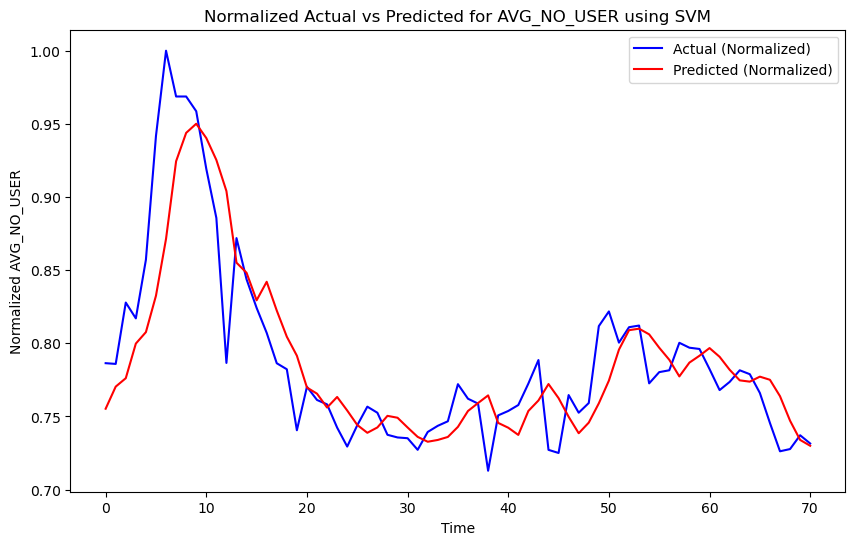

In [5]:


# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [6]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

Epoch 1/50
10/10 [==============================] - 25s 417ms/step - loss: 0.8074 - mae: 0.7210 - val_loss: 0.2518 - val_mae: 0.4981
Epoch 2/50
10/10 [==============================] - 2s 196ms/step - loss: 0.1786 - mae: 0.3274 - val_loss: 0.2484 - val_mae: 0.4947
Epoch 3/50
10/10 [==============================] - 2s 204ms/step - loss: 0.1482 - mae: 0.3097 - val_loss: 0.0236 - val_mae: 0.1415
Epoch 4/50
10/10 [==============================] - 2s 192ms/step - loss: 0.0857 - mae: 0.2287 - val_loss: 0.0126 - val_mae: 0.1061
Epoch 5/50
10/10 [==============================] - 2s 199ms/step - loss: 0.0568 - mae: 0.1933 - val_loss: 0.0111 - val_mae: 0.0866
Epoch 6/50
10/10 [==============================] - 2s 200ms/step - loss: 0.0423 - mae: 0.1640 - val_loss: 0.0037 - val_mae: 0.0471
Epoch 7/50
10/10 [==============================] - 2s 180ms/step - loss: 0.0378 - mae: 0.1538 - val_loss: 0.0148 - val_mae: 0.1061
Epoch 8/50
10/10 [==============================] - 2s 196ms/step - loss: 0

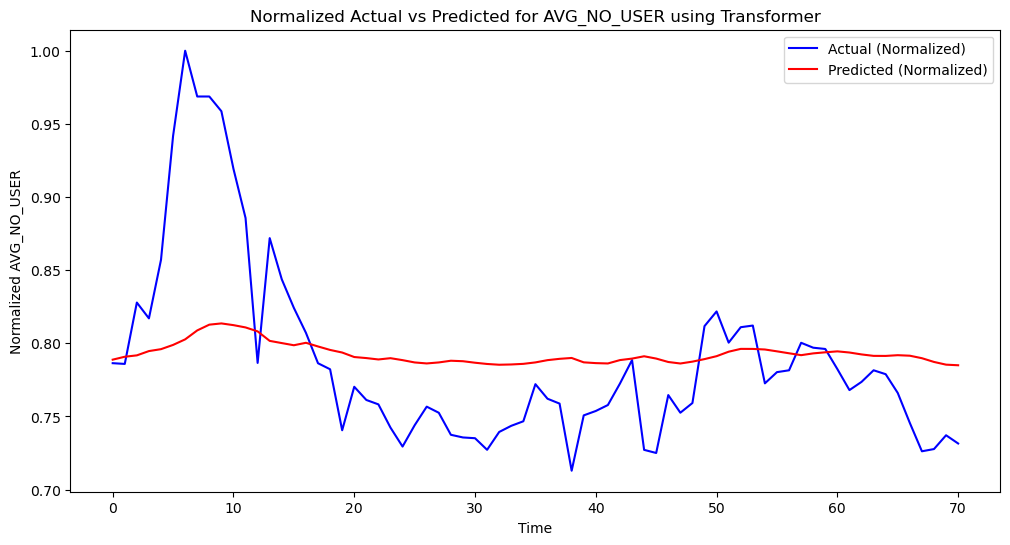

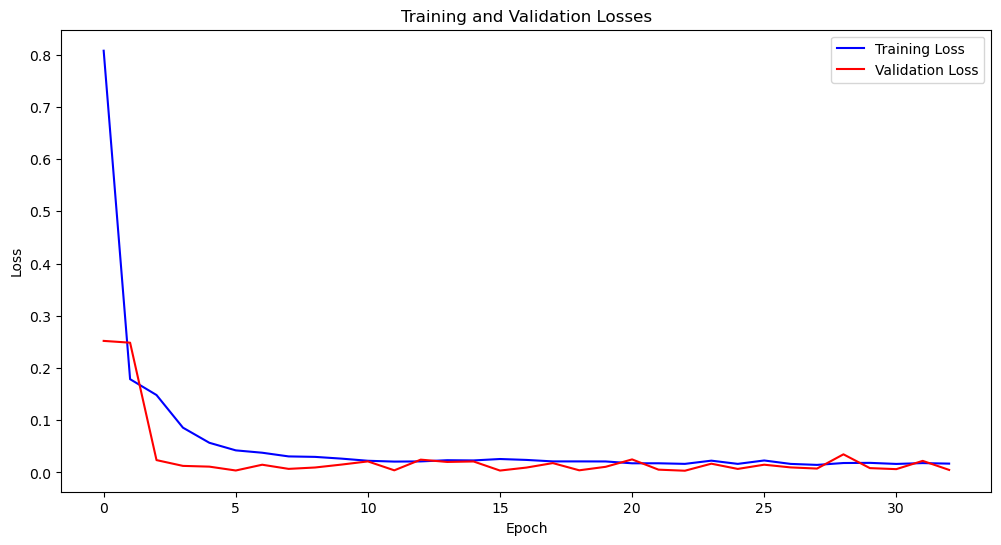


Final Metrics:
Training Loss: 0.0169
Validation Loss: 0.0049
Training MAE: 0.1038
Validation MAE: 0.0451


In [7]:
# Time Series Transformer Model
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TimeSeriesTransformer(keras.Model):
    def __init__(self, input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, 
                 mlp_units, dropout=0.1, mlp_dropout=0.1):
        super().__init__()
        self.embed = layers.Dense(head_size)
        self.transformer_blocks = [
            TransformerBlock(head_size, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_blocks)
        ]
        self.global_average = layers.GlobalAveragePooling1D()
        self.dropout = layers.Dropout(mlp_dropout)
        self.mlp_layers = []
        for dim in mlp_units:
            self.mlp_layers.append(layers.Dense(dim, activation="relu"))
            self.mlp_layers.append(layers.Dropout(mlp_dropout))
        self.output_layer = layers.Dense(1)

    def call(self, inputs):
        x = self.embed(inputs)
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x)
        x = self.global_average(x)
        for layer in self.mlp_layers:
            x = layer(x)
        return self.output_layer(x)

def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Prepare the data
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create datasets with look_back=3
look_back = 3
X_train, y_train = create_dataset(train, look_back=look_back)
X_test, y_test = create_dataset(test, look_back=look_back)

# Reshape input data for transformer (batch_size, seq_len, input_dim)
X_train = X_train.reshape(-1, look_back, 1)
X_test = X_test.reshape(-1, look_back, 1)

# Model parameters
head_size = 256
num_heads = 4
ff_dim = 4
num_transformer_blocks = 4
mlp_units = [128]
dropout = 0.1
mlp_dropout = 0.1

# Create and compile the model
model = TimeSeriesTransformer(
    input_shape=(look_back, 1),
    head_size=head_size,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_transformer_blocks=num_transformer_blocks,
    mlp_units=mlp_units,
    dropout=dropout,
    mlp_dropout=mlp_dropout
)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='mse',
    metrics=['mae']
)

# Train the model
batch_size = 32
epochs = 50
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True
        )
    ],
    verbose=1
)

# Make predictions
predictions = model.predict(X_test)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(predictions, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Transformer')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Print final metrics
print("\nFinal Metrics:")
print(f"Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"Training MAE: {history.history['mae'][-1]:.4f}")
print(f"Validation MAE: {history.history['val_mae'][-1]:.4f}")

Epoch 1/100
18/18 [==============================] - 86s 2s/step - loss: 0.9012 - val_loss: 0.0167 - lr: 9.9821e-05
Epoch 2/100
18/18 [==============================] - 39s 2s/step - loss: 0.0875 - val_loss: 0.0369 - lr: 9.9632e-05
Epoch 3/100
18/18 [==============================] - 39s 2s/step - loss: 0.0478 - val_loss: 0.0889 - lr: 9.9443e-05
Epoch 4/100
18/18 [==============================] - 39s 2s/step - loss: 0.0432 - val_loss: 0.0344 - lr: 9.9255e-05
Epoch 5/100
18/18 [==============================] - 39s 2s/step - loss: 0.0339 - val_loss: 0.0149 - lr: 9.9067e-05
Epoch 6/100
18/18 [==============================] - 39s 2s/step - loss: 0.0346 - val_loss: 0.0279 - lr: 9.8879e-05
Epoch 7/100
18/18 [==============================] - 39s 2s/step - loss: 0.0327 - val_loss: 0.0293 - lr: 9.8692e-05
Epoch 8/100
18/18 [==============================] - 39s 2s/step - loss: 0.0240 - val_loss: 0.0311 - lr: 9.8505e-05
Epoch 9/100
18/18 [==============================] - 39s 2s/step - loss:

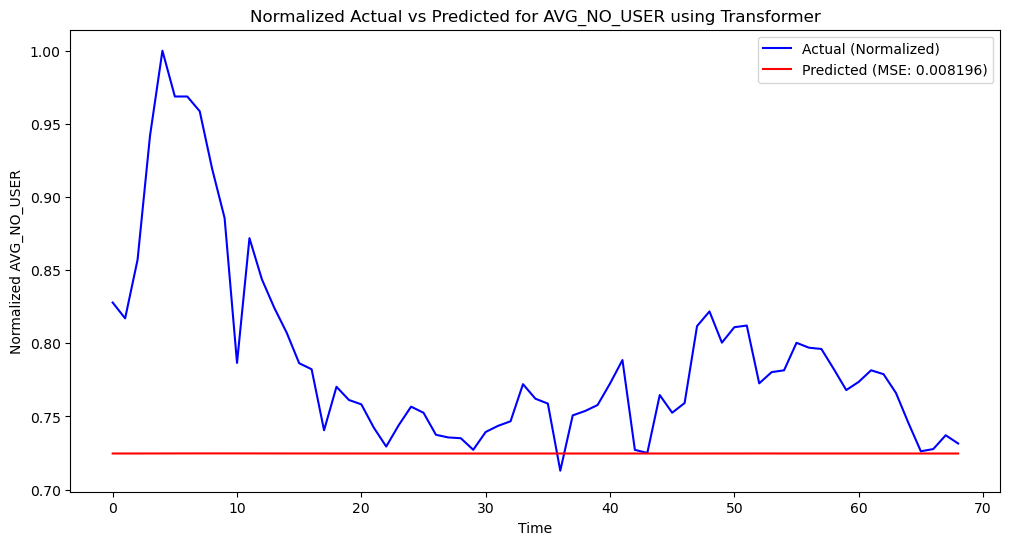

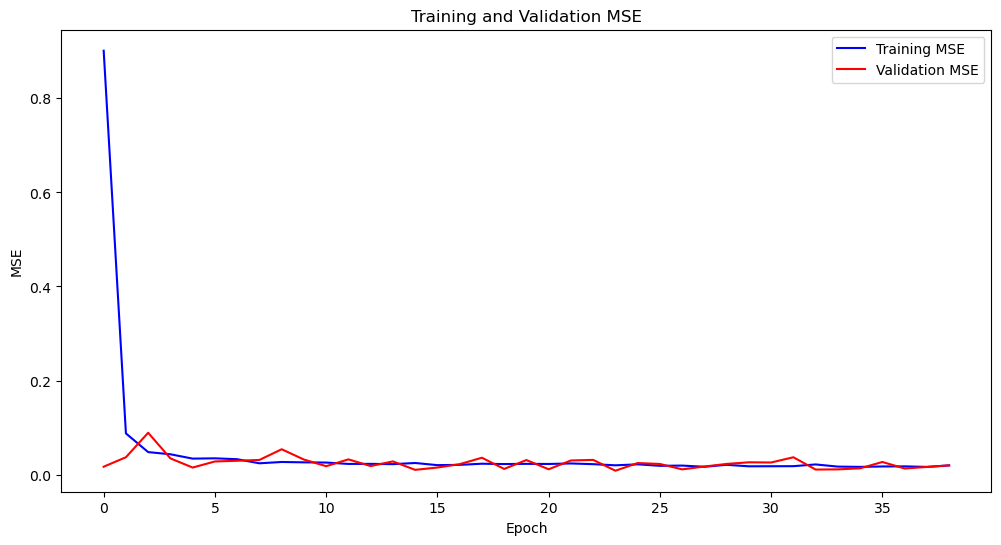

In [7]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),  # Changed to GELU activation
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class PositionalEncoding(layers.Layer):
    def __init__(self, sequence_length, embed_dim):
        super().__init__()
        self.pos_encoding = self.positional_encoding(sequence_length, embed_dim)

    def get_angles(self, pos, i, embed_dim):
        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(embed_dim))
        return pos * angle_rates

    def positional_encoding(self, sequence_length, embed_dim):
        angle_rads = self.get_angles(
            np.arange(sequence_length)[:, np.newaxis],
            np.arange(embed_dim)[np.newaxis, :],
            embed_dim
        )
        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        pos_encoding = angle_rads[np.newaxis, ...]
        return tf.cast(pos_encoding, dtype=tf.float32)

    def call(self, inputs):
        return inputs + self.pos_encoding[:, :tf.shape(inputs)[1], :]

class TimeSeriesTransformer(keras.Model):
    def __init__(self, input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, 
                 mlp_units, dropout=0.1, mlp_dropout=0.1):
        super().__init__()
        self.embed = layers.Dense(head_size)
        self.pos_encoding = PositionalEncoding(input_shape[0], head_size)
        self.transformer_blocks = [
            TransformerBlock(head_size, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_blocks)
        ]
        self.global_attention = layers.MultiHeadAttention(
            num_heads=1, key_dim=head_size
        )
        self.layernorm = layers.LayerNormalization(epsilon=1e-6)
        self.mlp_layers = []
        for dim in mlp_units:
            self.mlp_layers.append(layers.Dense(dim, activation="gelu"))
            self.mlp_layers.append(layers.Dropout(mlp_dropout))
        self.output_layer = layers.Dense(1)

    def call(self, inputs):
        x = self.embed(inputs)
        x = self.pos_encoding(x)
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x)
        
        # Global attention mechanism
        x = self.global_attention(x, x)
        x = self.layernorm(x)
        
        # Take the last sequence element
        x = x[:, -1, :]
        
        for layer in self.mlp_layers:
            x = layer(x)
        return self.output_layer(x)

def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Prepare the data
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create datasets with increased look_back
look_back = 5  # Increased from 3 to 5 for better context
X_train, y_train = create_dataset(train, look_back=look_back)
X_test, y_test = create_dataset(test, look_back=look_back)

# Reshape input data
X_train = X_train.reshape(-1, look_back, 1)
X_test = X_test.reshape(-1, look_back, 1)

# Optimized model parameters
head_size = 512  # Increased from 256
num_heads = 8    # Increased from 4
ff_dim = 4 * head_size  # Increased and made relative to head_size
num_transformer_blocks = 6  # Increased from 4
mlp_units = [256, 128]  # Added an extra layer
dropout = 0.15
mlp_dropout = 0.15

# Create and compile the model
model = TimeSeriesTransformer(
    input_shape=(look_back, 1),
    head_size=head_size,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_transformer_blocks=num_transformer_blocks,
    mlp_units=mlp_units,
    dropout=dropout,
    mlp_dropout=mlp_dropout
)

# Learning rate schedule
initial_learning_rate = 1e-4
decay_steps = 1000
decay_rate = 0.9
learning_rate_schedule = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, decay_steps, decay_rate
)

model.compile(
    optimizer=keras.optimizers.AdamW(  # Changed to AdamW
        learning_rate=learning_rate_schedule,
        weight_decay=1e-5
    ),
    loss='mse'  # Only using MSE now
)

# Train the model with increased epochs and modified batch size
batch_size = 16  # Reduced for better generalization
epochs = 100     # Increased from 50

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            min_delta=1e-5
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_delta=1e-5
        )
    ],
    verbose=1
)

# Make predictions and calculate MSE
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"\nTest MSE: {mse:.6f}")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(predictions, label=f'Predicted (MSE: {mse:.6f})', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Transformer')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training MSE', color='blue')
plt.plot(history.history['val_loss'], label='Validation MSE', color='red')
plt.title('Training and Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.show()


Epoch 1/200
100/100 [==============================] - 56s 263ms/step - loss: 1.4816 - val_loss: 0.1659 - lr: 9.9000e-06
Epoch 2/200
100/100 [==============================] - 7s 68ms/step - loss: 0.6127 - val_loss: 0.0777 - lr: 1.9900e-05
Epoch 3/200
100/100 [==============================] - 6s 58ms/step - loss: 0.3992 - val_loss: 0.0219 - lr: 2.9900e-05
Epoch 4/200
100/100 [==============================] - 5s 53ms/step - loss: 0.3414 - val_loss: 0.0205 - lr: 3.9900e-05
Epoch 5/200
100/100 [==============================] - 7s 71ms/step - loss: 0.3041 - val_loss: 0.0212 - lr: 4.9900e-05
Epoch 6/200
100/100 [==============================] - 6s 56ms/step - loss: 0.2438 - val_loss: 0.0125 - lr: 5.9900e-05
Epoch 7/200
100/100 [==============================] - 5s 46ms/step - loss: 0.1662 - val_loss: 0.0055 - lr: 6.9900e-05
Epoch 8/200
100/100 [==============================] - 7s 68ms/step - loss: 0.1167 - val_loss: 0.0062 - lr: 7.9900e-05
Epoch 9/200
100/100 [=========================

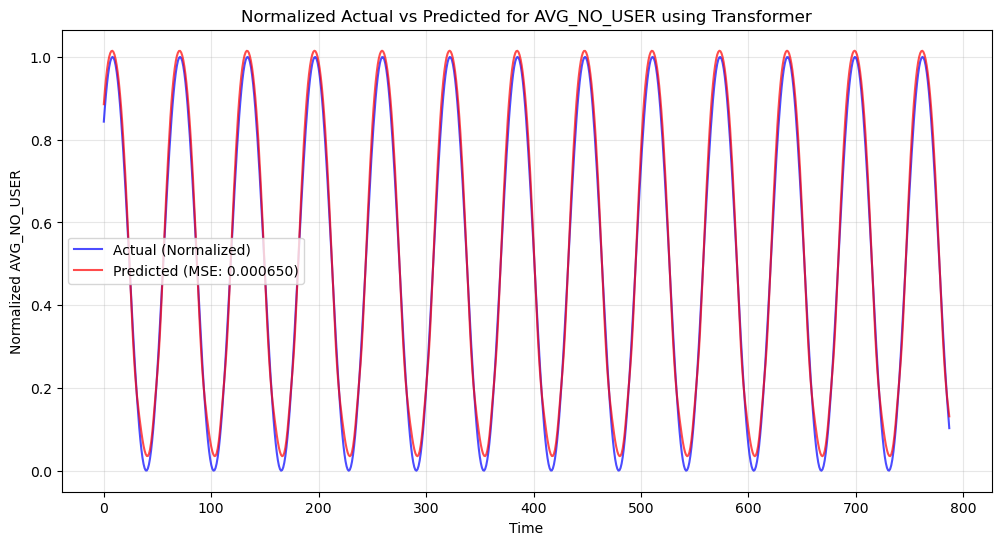

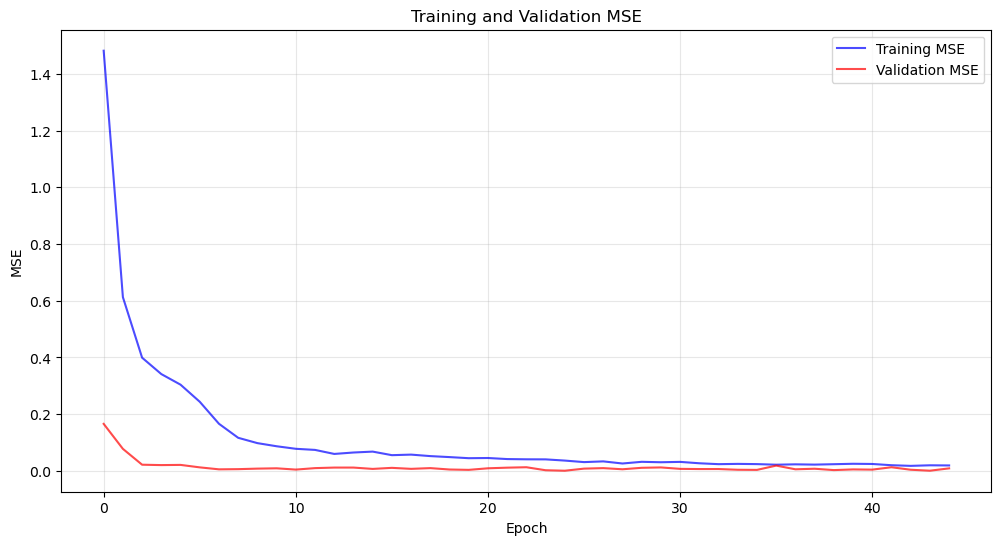

In [9]:
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),
            layers.Dense(embed_dim),
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training):
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

class TimeSeriesTransformer(keras.Model):
    def __init__(self, input_shape, head_size, num_heads, ff_dim, num_transformer_blocks, 
                 mlp_units, dropout=0.1, mlp_dropout=0.1):
        super().__init__()
        
        # Initial processing
        self.input_proj = layers.Conv1D(filters=head_size, kernel_size=1)
        
        # Positional encoding
        self.positions = tf.range(start=0, limit=input_shape[0], delta=1)
        self.pos_embedding = layers.Embedding(input_dim=input_shape[0], output_dim=head_size)
        
        # Transformer blocks
        self.transformer_blocks = [
            TransformerBlock(head_size, num_heads, ff_dim, dropout)
            for _ in range(num_transformer_blocks)
        ]
        
        # Processing branches
        self.local_branch = layers.Conv1D(filters=head_size, kernel_size=3, padding='same')
        self.global_branch = layers.GlobalAveragePooling1D()
        
        # Final processing
        self.concat_projection = layers.Dense(head_size)
        self.mlp_layers = []
        for dim in mlp_units:
            self.mlp_layers.extend([
                layers.Dense(dim, activation="gelu"),
                layers.Dropout(mlp_dropout),
                layers.LayerNormalization(epsilon=1e-6)
            ])
        
        self.output_layer = layers.Dense(1)

    def call(self, inputs, training=True):
        # Initial processing
        x = self.input_proj(inputs)
        
        # Add positional encoding
        positions = tf.broadcast_to(
            self.positions, [tf.shape(inputs)[0], tf.shape(inputs)[1]]
        )
        pos_embedding = self.pos_embedding(positions)
        x = x + pos_embedding
        
        # Transformer processing
        attention_outputs = []
        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, training)
            attention_outputs.append(x)
        
        # Multi-scale feature extraction
        local_features = self.local_branch(x)
        global_features = self.global_branch(x)
        global_features = tf.broadcast_to(
            global_features[:, tf.newaxis, :],
            [tf.shape(local_features)[0], tf.shape(local_features)[1], tf.shape(local_features)[2]]
        )
        
        # Combine features
        combined_features = tf.concat([local_features, global_features], axis=-1)
        x = self.concat_projection(combined_features)
        
        # Final prediction using the last time step
        x = x[:, -1, :]
        
        # MLP layers
        for layer in self.mlp_layers:
            x = layer(x)
            
        return self.output_layer(x)

def create_dataset(dataset, look_back=1):
    X, y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)

# Prepare the data
feature = 'AVG_NO_USER'
data = np.sin(np.arange(0, 400, 0.1)).reshape(-1, 1)  # Mock dataset
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

# Split the data
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create datasets with increased look_back
look_back = 12  # Increased for better pattern capture
X_train, y_train = create_dataset(train, look_back=look_back)
X_test, y_test = create_dataset(test, look_back=look_back)

# Reshape input data
X_train = X_train.reshape(-1, look_back, 1)
X_test = X_test.reshape(-1, look_back, 1)

# Model parameters
head_size = 64
num_heads = 4
ff_dim = 128
num_transformer_blocks = 3
mlp_units = [32, 16]
dropout = 0.1
mlp_dropout = 0.1

# Create and compile the model
model = TimeSeriesTransformer(
    input_shape=(look_back, 1),
    head_size=head_size,
    num_heads=num_heads,
    ff_dim=ff_dim,
    num_transformer_blocks=num_transformer_blocks,
    mlp_units=mlp_units,
    dropout=dropout,
    mlp_dropout=mlp_dropout
)

# Custom learning rate schedule
class WarmUpCosine(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_learning_rate, decay_steps, warmup_steps=1000):
        super().__init__()
        self.initial_learning_rate = initial_learning_rate
        self.decay_steps = decay_steps
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        pi = tf.constant(np.pi, dtype=tf.float32)
        step = tf.cast(step, tf.float32)  # Ensure `step` is a float tensor
        cosine_decay = 0.5 * (1 + tf.cos(pi * (step - self.warmup_steps) / self.decay_steps))
        warmup = step / self.warmup_steps
        return self.initial_learning_rate * tf.where(
            step < self.warmup_steps,
            warmup,
            cosine_decay
        )

# Compile model with custom learning rate schedule
initial_learning_rate = 1e-4
warmup_steps = 1000
decay_steps = 10000

lr_schedule = WarmUpCosine(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    warmup_steps=warmup_steps
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-5
)

model.compile(optimizer=optimizer, loss='mse')

# Train with increased batch size and epochs
batch_size = 32
epochs = 200

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            min_delta=1e-6
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=10,
            min_delta=1e-6
        )
    ],
    verbose=1
)

# Make predictions and calculate MSE
predictions = model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
print(f"\nTest MSE: {mse:.6f}")

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue', alpha=0.7)
plt.plot(predictions, label=f'Predicted (MSE: {mse:.6f})', color='red', alpha=0.7)
plt.title(f'Normalized Actual vs Predicted for {feature} using Transformer')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training MSE', color='blue', alpha=0.7)
plt.plot(history.history['val_loss'], label='Validation MSE', color='red', alpha=0.7)
plt.title('Training and Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.23080864765910963
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.23080864765910963
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.03195585296716754
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.03195585296716754
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.01317600859138989
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.01317600859138989
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.3542831377818642
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.3149190092981354
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.3427594726813366
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.1235761096196439
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.39302215092958454
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.08648342829794978
Training

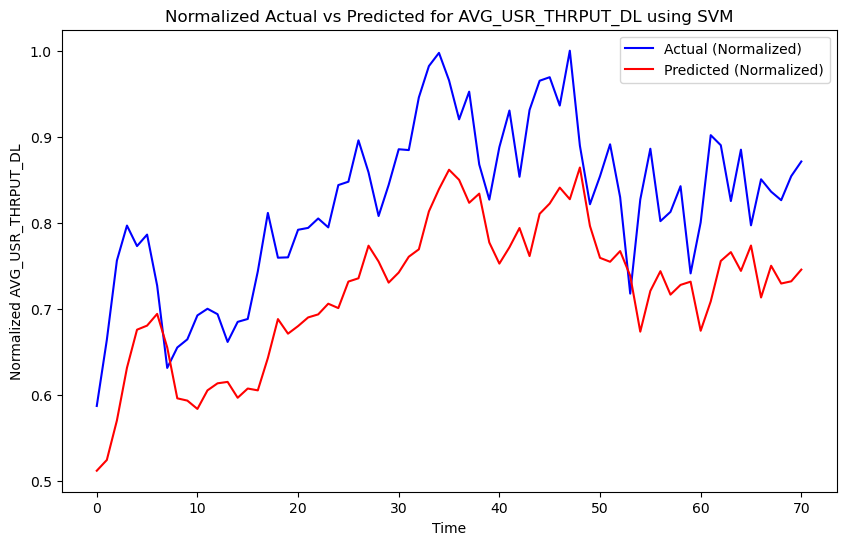

In [70]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Training with kernel=linear, C=0.1, gamma=scale
MSE (normalized): 0.012883622376397109
Training with kernel=linear, C=0.1, gamma=auto
MSE (normalized): 0.012883622376397109
Training with kernel=linear, C=1, gamma=scale
MSE (normalized): 0.006446489851100472
Training with kernel=linear, C=1, gamma=auto
MSE (normalized): 0.006446489851100472
Training with kernel=linear, C=10, gamma=scale
MSE (normalized): 0.004331244809997847
Training with kernel=linear, C=10, gamma=auto
MSE (normalized): 0.004331244809997847
Training with kernel=rbf, C=0.1, gamma=scale
MSE (normalized): 0.020019004478182174
Training with kernel=rbf, C=0.1, gamma=auto
MSE (normalized): 0.014322352379421291
Training with kernel=rbf, C=1, gamma=scale
MSE (normalized): 0.030239646178131196
Training with kernel=rbf, C=1, gamma=auto
MSE (normalized): 0.00639487605203085
Training with kernel=rbf, C=10, gamma=scale
MSE (normalized): 0.023687473864966203
Training with kernel=rbf, C=10, gamma=auto
MSE (normalized): 0.002106825979

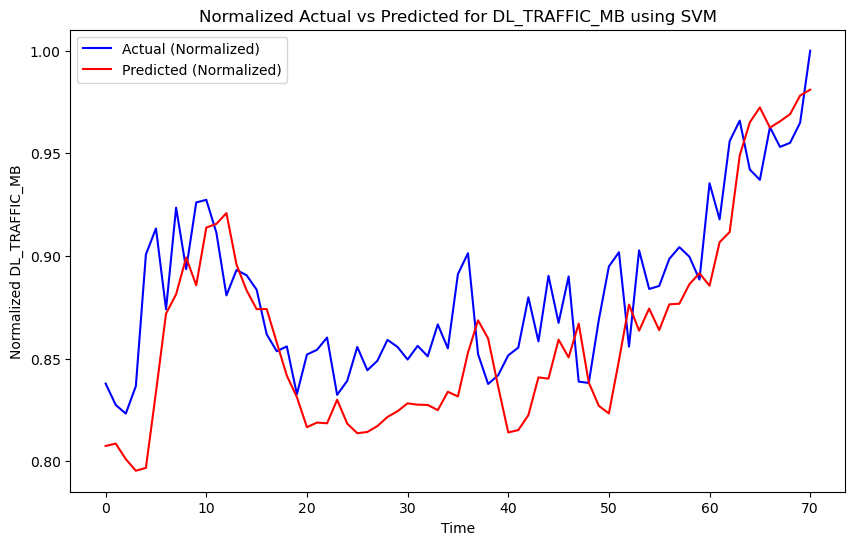

In [72]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area4.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to a 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_svm(train, look_back=look_back)
X_test, y_test = create_dataset_svm(test, look_back=look_back)

# Train SVM model with different hyperparameters
best_mse = float('inf')
best_params = {}
best_model = None

# Hyperparameter tuning loop for SVM
for kernel in ['linear', 'rbf', 'poly']:
    for C in [0.1, 1, 10]:
        for gamma in ['scale', 'auto']:
            print(f'Training with kernel={kernel}, C={C}, gamma={gamma}')
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train, y_train)
            
            # Predict and calculate MSE
            test_predict = svm_model.predict(X_test)
            mse = mean_squared_error(y_test, test_predict)
            print(f'MSE (normalized): {mse}')
            
            # Track the best model
            if mse < best_mse:
                best_mse = mse
                best_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_model = svm_model

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test)

# Plot the best model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using SVM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [39]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]


In [40]:
from sklearn.svm import SVR
from sklearn.preprocessing import MaxAbsScaler

from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.layers import Dense, GRU, Dropout



Epoch 1/50
9/9 [==============================] - 10s 259ms/step - loss: 0.1138 - val_loss: 0.0011
Epoch 2/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0222 - val_loss: 9.4542e-04
Epoch 3/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0085 - val_loss: 0.0136
Epoch 4/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0090 - val_loss: 6.2716e-04
Epoch 5/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0076 - val_loss: 3.1748e-04
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0065 - val_loss: 0.0027
Epoch 7/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0059 - val_loss: 6.4884e-04
Epoch 8/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0057 - val_loss: 6.3244e-04
Epoch 9/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0055 - val_loss: 0.0014
Epoch 10/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0053 - val_loss: 6.3290e-04
Epo

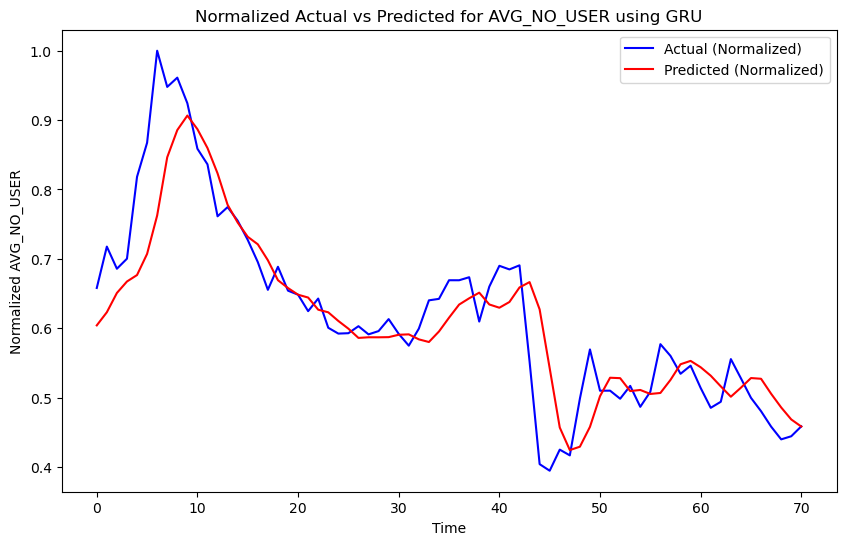

In [41]:
# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)
# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 8s 228ms/step - loss: 0.0235 - val_loss: 0.0015
Epoch 2/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0087 - val_loss: 8.1351e-04
Epoch 3/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0057 - val_loss: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0050 - val_loss: 7.2432e-04
Epoch 5/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0047 - val_loss: 8.5395e-04
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0044 - val_loss: 7.9125e-04
Epoch 7/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0044 - val_loss: 8.2501e-04
Epoch 8/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0046 - val_loss: 7.6220e-04
Epoch 9/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0045 - val_loss: 7.4187e-04
Epoch 10/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0043 - val_loss: 7.5984e

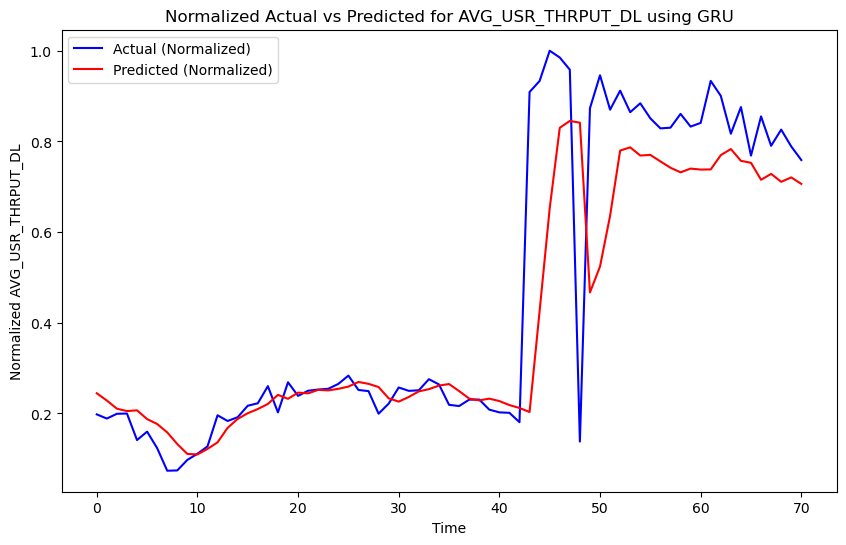

In [42]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 10s 263ms/step - loss: 0.2845 - val_loss: 0.0242
Epoch 2/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0321 - val_loss: 0.0287
Epoch 3/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0167 - val_loss: 0.0125
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0154 - val_loss: 0.0170
Epoch 5/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0094 - val_loss: 6.1930e-04
Epoch 6/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0083 - val_loss: 9.7402e-04
Epoch 7/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0075 - val_loss: 0.0036
Epoch 8/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0067 - val_loss: 0.0021
Epoch 9/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0063 - val_loss: 0.0013
Epoch 10/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0067 - val_loss: 0.0017
Epoch 11/50
9/9 [==

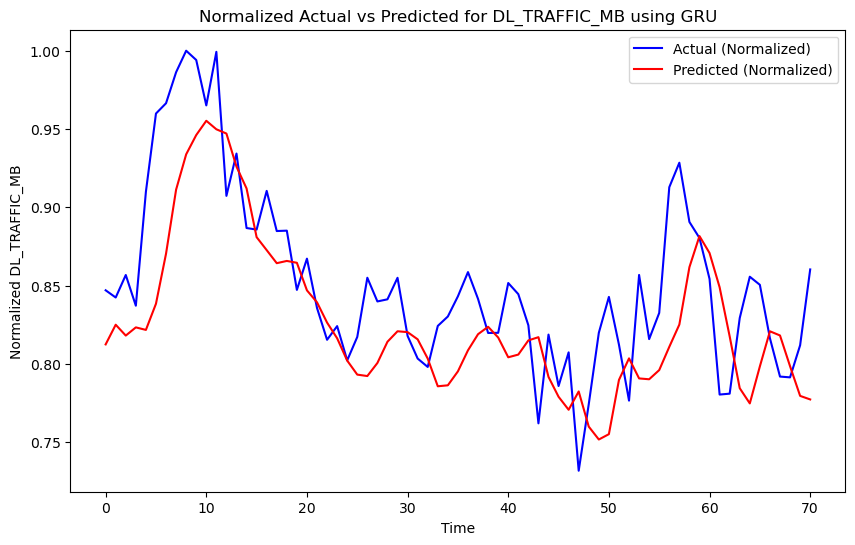

In [43]:
# Function to create dataset matrix for GRU
def create_dataset_gru(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for GRU (look_back=3)
look_back = 3
X_train, y_train = create_dataset_gru(train, look_back=look_back)
X_test, y_test = create_dataset_gru(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for GRU
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 1))
gru_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train)
test_predict_gru = gru_model.predict(X_test)

# Calculate MSE for the GRU model
gru_mse = mean_squared_error(y_test, test_predict_gru)
print(f'GRU Model MSE (Normalized): {gru_mse}')

# Plot the GRU model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using GRU')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 9s 161ms/step - loss: 0.2600 - val_loss: 0.2167
Epoch 2/50
9/9 [==============================] - 0s 11ms/step - loss: 0.1005 - val_loss: 0.0273
Epoch 3/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0134 - val_loss: 0.0137
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0142 - val_loss: 0.0040
Epoch 5/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0083 - val_loss: 0.0072
Epoch 6/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0075 - val_loss: 7.6482e-04
Epoch 7/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0068 - val_loss: 8.6100e-04
Epoch 8/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0065 - val_loss: 0.0020
Epoch 9/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0061 - val_loss: 5.8736e-04
Epoch 10/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0066 - val_loss: 6.5481e-04
Epoch 11/50


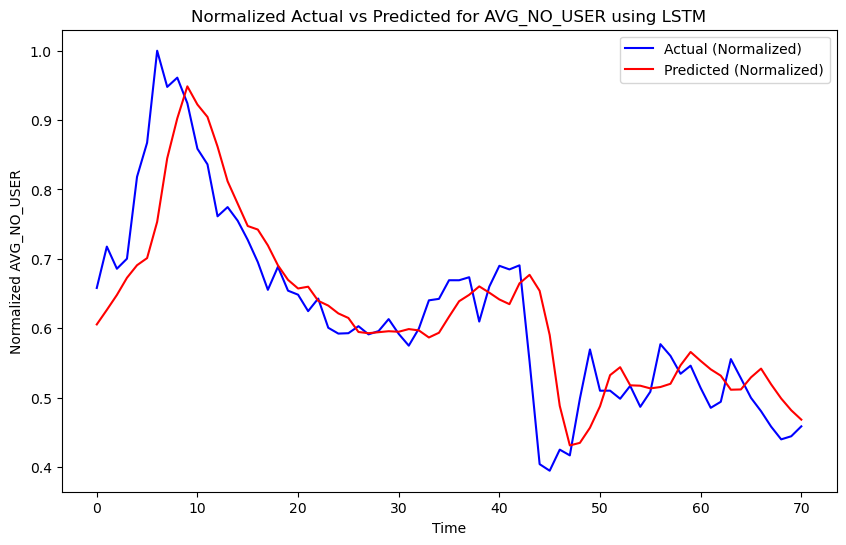

In [44]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 8s 135ms/step - loss: 0.0341 - val_loss: 0.0116
Epoch 2/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0101 - val_loss: 0.0021
Epoch 3/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0099 - val_loss: 9.3210e-04
Epoch 4/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0075 - val_loss: 0.0020
Epoch 5/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0063 - val_loss: 7.7378e-04
Epoch 6/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0056 - val_loss: 9.4178e-04
Epoch 7/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0049 - val_loss: 8.1419e-04
Epoch 8/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0048 - val_loss: 8.9883e-04
Epoch 9/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0047 - val_loss: 9.3598e-04
Epoch 10/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0050 - val_loss: 8.6156e-04
Epoch 11/

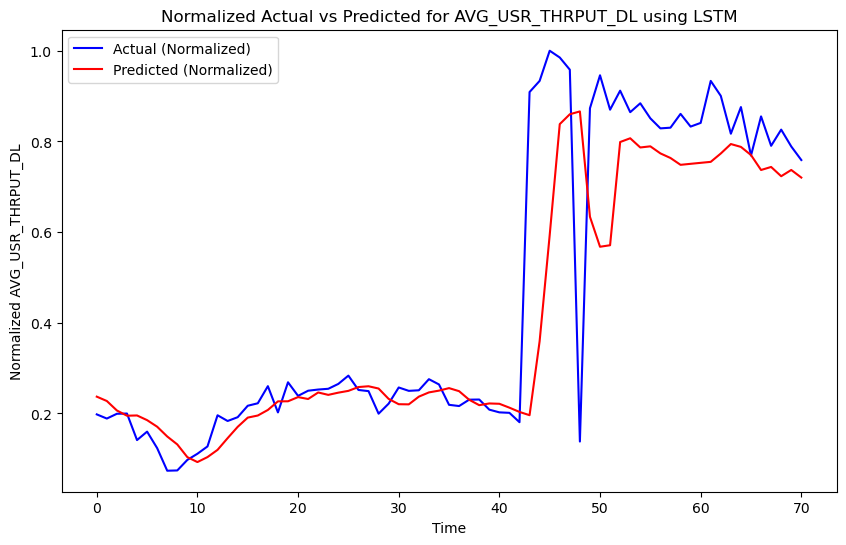

In [45]:
# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 23s 447ms/step - loss: 0.1409 - val_loss: 0.0482
Epoch 2/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0161 - val_loss: 0.0136
Epoch 3/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0098 - val_loss: 0.0102
Epoch 4/50
9/9 [==============================] - 0s 30ms/step - loss: 0.0083 - val_loss: 0.0029
Epoch 5/50
9/9 [==============================] - 0s 29ms/step - loss: 0.0045 - val_loss: 8.3470e-04
Epoch 6/50
9/9 [==============================] - 0s 28ms/step - loss: 0.0044 - val_loss: 0.0029
Epoch 7/50
9/9 [==============================] - 0s 25ms/step - loss: 0.0039 - val_loss: 9.5963e-04
Epoch 8/50
9/9 [==============================] - 0s 32ms/step - loss: 0.0038 - val_loss: 0.0013
Epoch 9/50
9/9 [==============================] - 0s 29ms/step - loss: 0.0033 - val_loss: 0.0015
Epoch 10/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0035 - val_loss: 0.0010
Epoch 11/50
9/9 [==

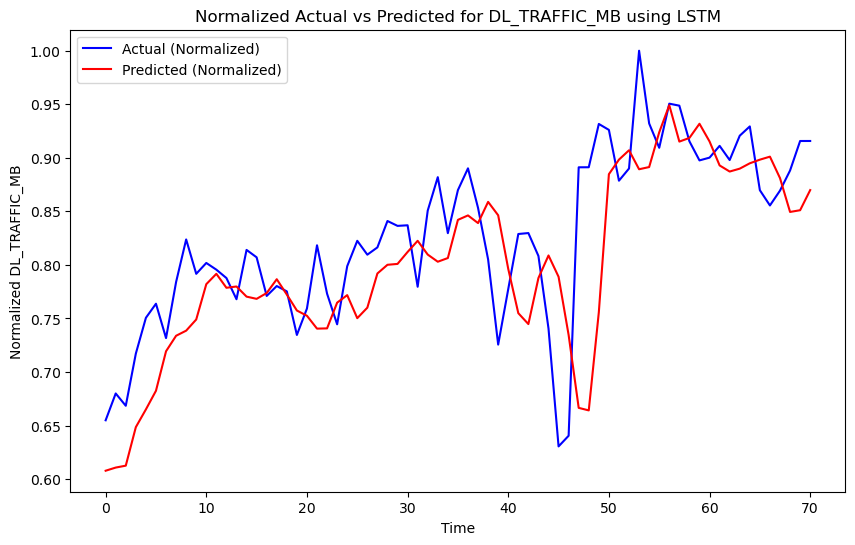

In [74]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

# Function to create dataset matrix for LSTM
def create_dataset_lstm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=3)
look_back = 3
X_train, y_train = create_dataset_lstm(train, look_back=look_back)
X_test, y_test = create_dataset_lstm(test, look_back=look_back)

# Reshape input to be [samples, timesteps, features] for LSTM
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Define the LSTM model
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(150, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.3))
    model.add(LSTM(100, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression
    
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train LSTM model
lstm_model = build_lstm_model((look_back, 1))
lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the LSTM model
train_predict_lstm = lstm_model.predict(X_train)
test_predict_lstm = lstm_model.predict(X_test)

# Calculate MSE for the LSTM model
lstm_mse = mean_squared_error(y_test, test_predict_lstm)
print(f'LSTM Model MSE (Normalized): {lstm_mse}')

# Plot the LSTM model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using LSTM')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

ARIMA Model MSE (Normalized): 0.009403614410521116


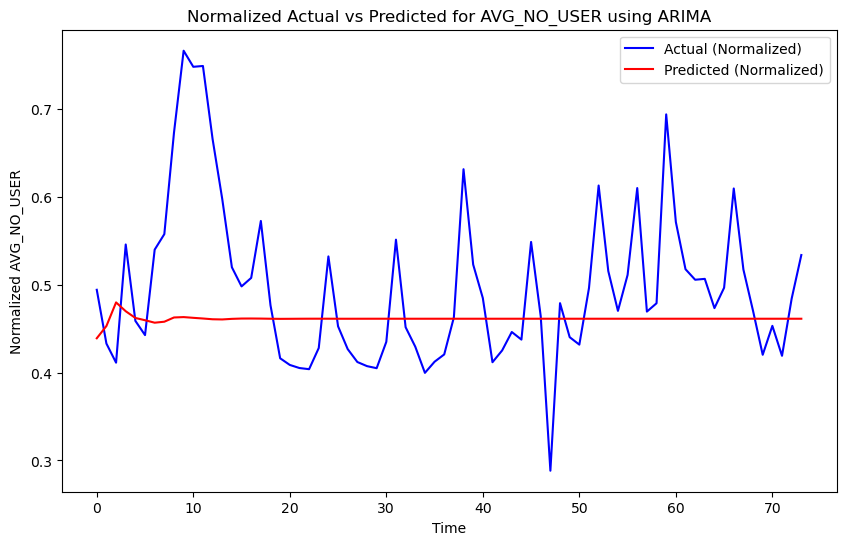

In [75]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area2.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'

# Normalize the 'Avg_Usr' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
import matplotlib.pyplot as plt

In [103]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area4.csv')


In [91]:
data

,Date,AVG_NO_USER,AVG_USR_THRPUT_DL,DL_TRAFFIC_MB
0,2022-09-01 00:00:00,16209.61,771.91,28748026.10
1,2022-09-02 00:00:00,16003.68,728.12,29619777.66
2,2022-09-03 00:00:00,16058.39,805.73,29102851.45
3,2022-09-04 00:00:00,16390.15,834.78,28466880.25
4,2022-09-05 00:00:00,16051.58,834.73,28558733.04
...,...,...,...,...
361,2023-08-28 00:00:00,23298.68,3723.24,56768939.70
362,2023-08-29 00:00:00,24511.92,3671.32,57456743.34
363,2023-08-30 00:00:00,24467.48,3635.56,58389814.53
364,2023-08-31 00:00:00,23803.97,3736.53,59759544.72


ARIMA Model MSE (Normalized): 0.06291342318685741


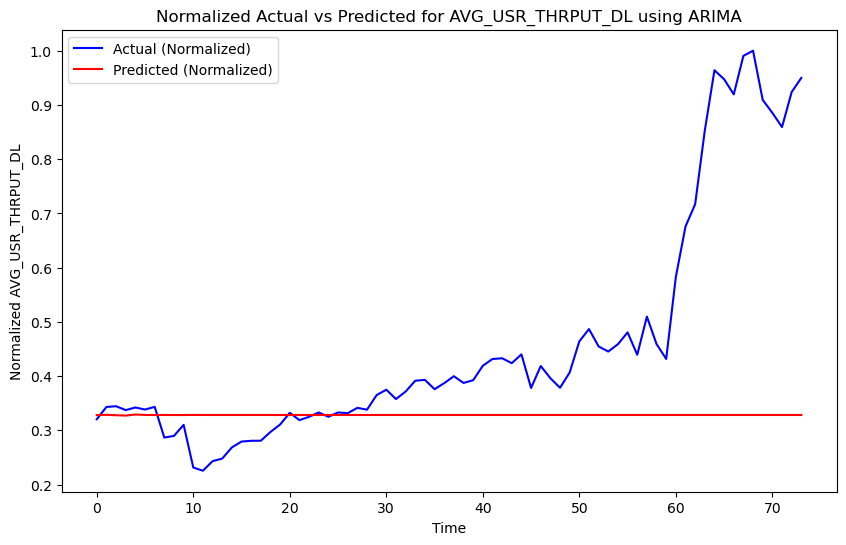

In [104]:

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

ARIMA Model MSE (Normalized): 0.008853195640163973


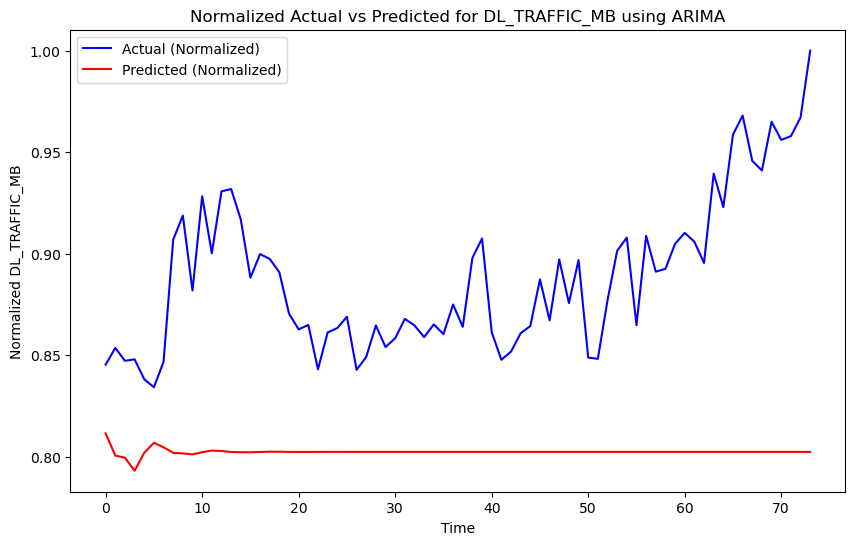

In [102]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area4.csv')

# Preparing data for 'AVG_NO_USER'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Fit the ARIMA model
# (p, d, q) are ARIMA parameters. Start with simple values like (p=5, d=1, q=0)
model = ARIMA(train, order=(5, 1, 0))  # You can experiment with these values
arima_model = model.fit()

# Make predictions on test data
test_predict_arima = arima_model.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=-1391.307, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-1380.242, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-1384.015, Time=0.10 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-1385.604, Time=0.25 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-1381.197, Time=0.11 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-1385.738, Time=0.37 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=-1387.255, Time=0.37 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=-1389.202, Time=0.43 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-1387.738, Time=0.16 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-1389.285, Time=0.65 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=-1389.892, Time=0.23 sec

Best model:  ARIMA(1,1,1)(0,0,0)[0] intercept
Total fit time: 3.190 seconds
Optimized ARIMA Model MSE (Normalized): 0.14339899203891524


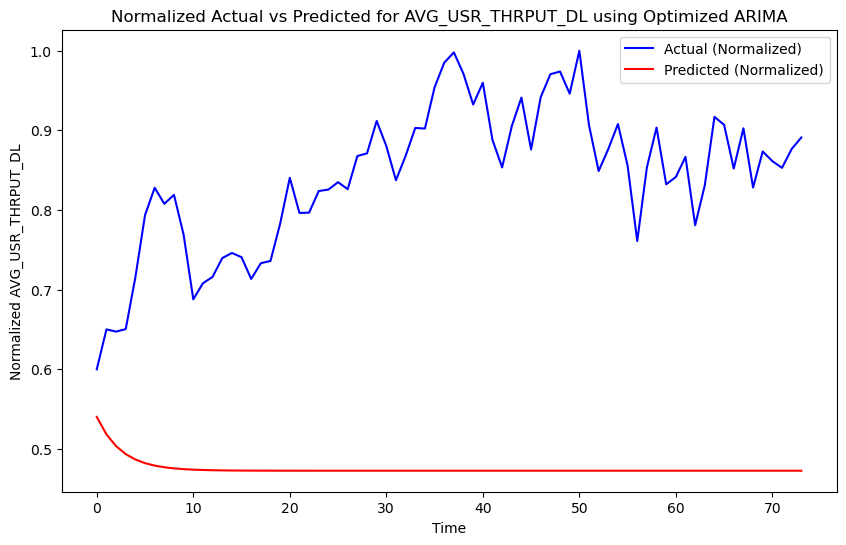

In [116]:
# Load your dataset
#data = pd.read_csv('../../data/Area3.csv')

# Prepare data for 'AVG_NO_USER'
feature = 'AVG_USR_THRPUT_DL'

# Normalize the 'AVG_USR_THRPUT_DL' data
#scaler = MinMaxScaler(feature_range=(0, 1))
#scaled_data = scaler.fit_transform(data[[feature]])

# Initialize the MaxAbsScaler
scaler = MaxAbsScaler()

# Normalize the 'Traffic' data
scaled_data = scaler.fit_transform(data[[feature]])


# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Flatten the data for ARIMA (since it expects 1D arrays)
train = train.flatten()
test = test.flatten()

# Find the best ARIMA parameters
stepwise_model = auto_arima(train, start_p=1, start_q=1,
                            max_p=6, max_q=6, m=1,
                            start_P=0, seasonal=False,
                            d=1, trace=True,
                            error_action='ignore',  
                            suppress_warnings=True, 
                            stepwise=True)

# Fit the ARIMA model with the optimal parameters
arima_model = ARIMA(train, order=stepwise_model.order)
arima_model_fit = arima_model.fit()

# Make predictions on test data
test_predict_arima = arima_model_fit.forecast(steps=len(test))

# Calculate MSE for ARIMA model
arima_mse = mean_squared_error(test, test_predict_arima)
print(f'Optimized ARIMA Model MSE (Normalized): {arima_mse}')

# Plot the ARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_arima, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Optimized ARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [115]:
# Load your dataset
data = pd.read_csv('../../data/Area3.csv')

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=inf, Time=1.80 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=-1160.990, Time=0.05 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=-1219.232, Time=0.38 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=inf, Time=1.21 sec
 ARIMA(1,1,0)(0,1,0)[12]             : AIC=-1164.409, Time=0.10 sec
 ARIMA(1,1,0)(2,1,0)[12]             : AIC=-1232.953, Time=0.90 sec
 ARIMA(1,1,0)(2,1,1)[12]             : AIC=inf, Time=4.72 sec
 ARIMA(1,1,0)(1,1,1)[12]             : AIC=inf, Time=1.33 sec
 ARIMA(0,1,0)(2,1,0)[12]             : AIC=-1231.464, Time=1.13 sec
 ARIMA(2,1,0)(2,1,0)[12]             : AIC=-1239.108, Time=1.64 sec
 ARIMA(2,1,0)(1,1,0)[12]             : AIC=-1225.635, Time=0.39 sec
 ARIMA(2,1,0)(2,1,1)[12]             : AIC=inf, Time=3.03 sec
 ARIMA(2,1,0)(1,1,1)[12]             : AIC=inf, Time=1.67 sec
 ARIMA(3,1,0)(2,1,0)[12]             : AIC=-1237.200, Time=1.02 sec
 ARIMA(2,1,1)(2,1,0)[12]             : AI

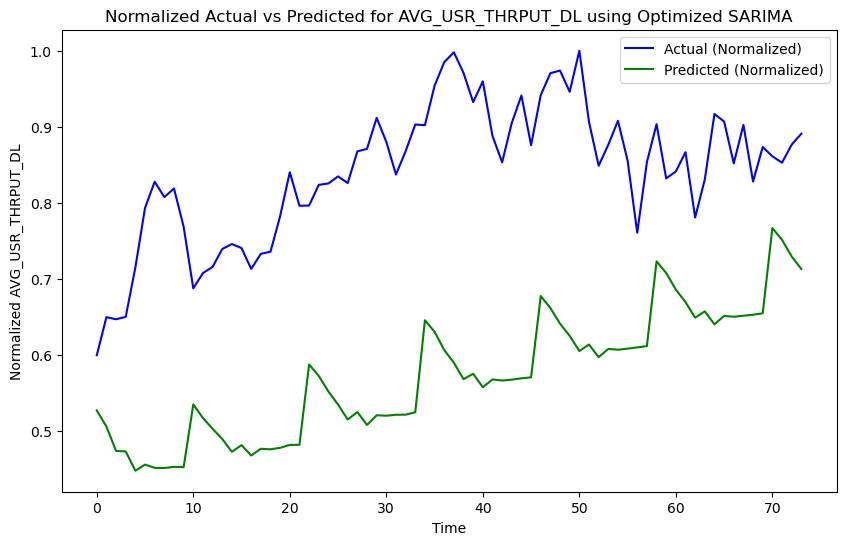

In [117]:
# Try SARIMA model with seasonal adjustment
stepwise_model_seasonal = auto_arima(train, start_p=1, start_q=1,
                                     max_p=6, max_q=6, m=12,  # Set m to your data's seasonal frequency
                                     start_P=0, seasonal=True,
                                     d=1, D=1, trace=True,
                                     error_action='ignore',  
                                     suppress_warnings=True, 
                                     stepwise=True)

# Fit the SARIMA model with the optimal parameters
sarima_model = ARIMA(train, order=stepwise_model_seasonal.order, seasonal_order=stepwise_model_seasonal.seasonal_order)
sarima_model_fit = sarima_model.fit()

# Forecast with SARIMA model
test_predict_sarima = sarima_model_fit.forecast(steps=len(test))

# Calculate MSE for SARIMA model
sarima_mse = mean_squared_error(test, test_predict_sarima)
print(f'Optimized SARIMA Model MSE (Normalized): {sarima_mse}')

# Plot the SARIMA model's predictions with actual values
plt.figure(figsize=(10, 6))
plt.plot(test, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_sarima, label='Predicted (Normalized)', color='green')
plt.title(f'Normalized Actual vs Predicted for {feature} using Optimized SARIMA')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [118]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import matplotlib.pyplot as plt

Epoch 1/50
9/9 [==============================] - 27s 303ms/step - loss: 0.0844 - val_loss: 0.0161
Epoch 2/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0268 - val_loss: 0.0013
Epoch 3/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0113 - val_loss: 0.0101
Epoch 4/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0069 - val_loss: 0.0037
Epoch 5/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0061 - val_loss: 0.0012
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0041 - val_loss: 0.0015
Epoch 7/50
9/9 [==============================] - 0s 30ms/step - loss: 0.0032 - val_loss: 0.0022
Epoch 8/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 9/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 10/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0029 - val_loss: 0.0014
Epoch 11/50
9/9 [==========

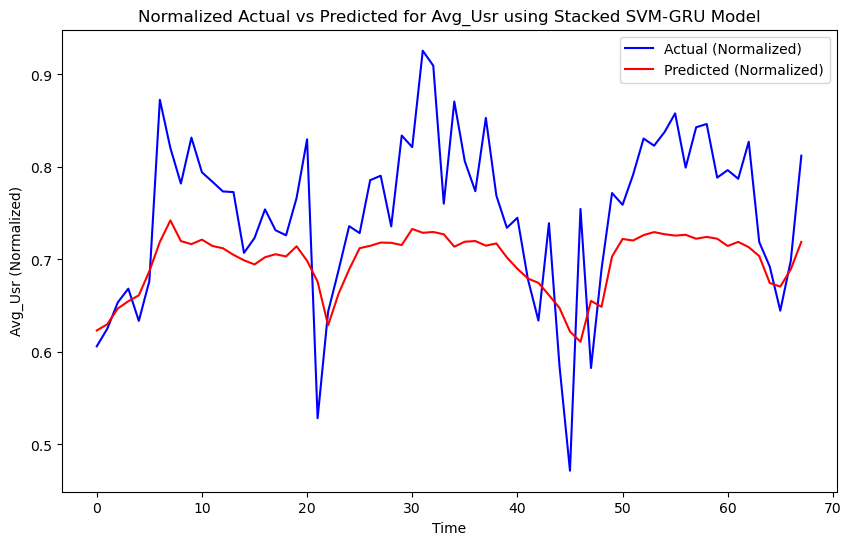

In [119]:

# Load your dataset (adjust the path to where your file is located)
#data = pd.read_csv('../../data/Area2.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 8s 151ms/step - loss: 0.0354 - val_loss: 0.0101
Epoch 2/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0114 - val_loss: 0.0031
Epoch 3/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0058 - val_loss: 0.0028
Epoch 4/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 5/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0025 - val_loss: 7.9122e-04
Epoch 7/50
9/9 [==============================] - 0s 25ms/step - loss: 0.0022 - val_loss: 7.1466e-04
Epoch 8/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0021 - val_loss: 7.7927e-04
Epoch 9/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0019 - val_loss: 9.5983e-04
Epoch 10/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0018 - val_loss: 7.4733e-04
Epoch 11

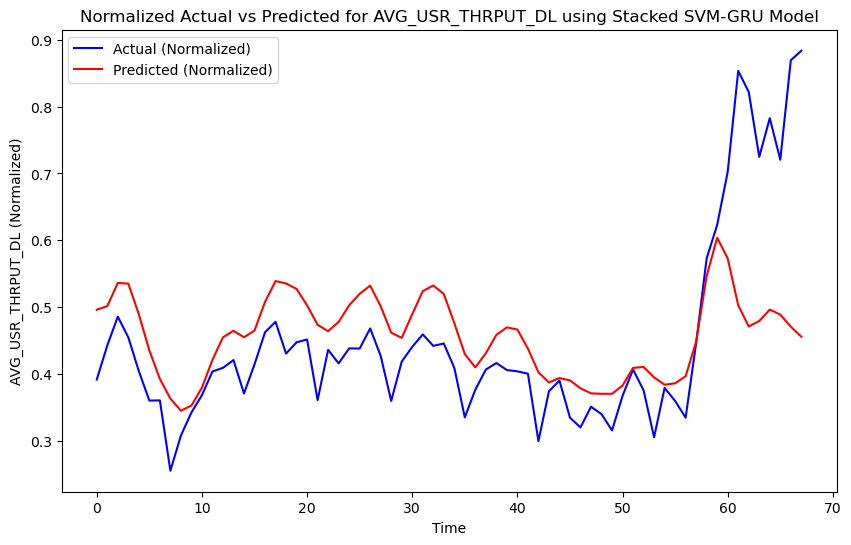

In [128]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area2.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_USR_THRPUT_DL'
feature = 'AVG_USR_THRPUT_DL'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel(f'{feature} (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 10s 197ms/step - loss: 0.1718 - val_loss: 0.0202
Epoch 2/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0346 - val_loss: 4.3047e-04
Epoch 3/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0113 - val_loss: 0.0142
Epoch 4/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0087 - val_loss: 4.3364e-04
Epoch 5/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0080 - val_loss: 7.2436e-04
Epoch 6/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0063 - val_loss: 0.0011
Epoch 7/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0064 - val_loss: 0.0024
Epoch 8/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0137 - val_loss: 0.0091
Epoch 9/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0081 - val_loss: 0.0023
Epoch 10/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0083 - val_loss: 0.0025
Epoch 11/50
9/9

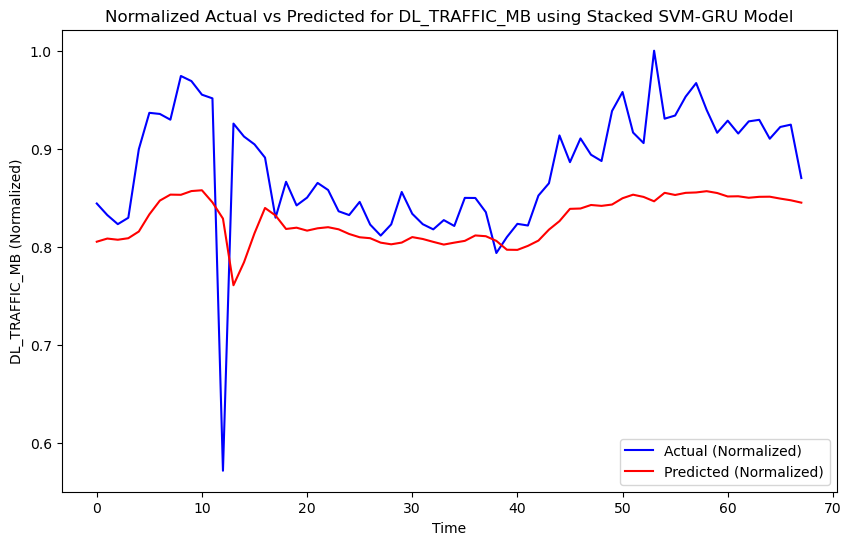

In [126]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area1.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Traffic'
feature = 'DL_TRAFFIC_MB'

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])


# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define and train the GRU model
def build_gru_model(input_shape):
    model = Sequential()
    model.add(GRU(100, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    model.add(Dense(1))  # Output layer for regression

    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train GRU model
gru_model = build_gru_model((look_back, 2))
gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the GRU model
train_predict_gru = gru_model.predict(X_train_gru)
test_predict_gru = gru_model.predict(X_test_gru)

# No need to invert the values; everything stays normalized

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature} using Stacked SVM-GRU Model')
plt.xlabel('Time')
plt.ylabel(f'{feature} (Normalized)')
plt.legend()
plt.show()

In [57]:
data

,Date,AVG_NO_USER,DL_TRAFFIC_MB,AVG_USR_THRPUT_DL
0,2022-09-01 00:00:00,236.47,477293.49,3.246667
1,2022-09-02 00:00:00,246.26,498918.08,3.093333
2,2022-09-03 00:00:00,239.56,486175.40,3.566667
3,2022-09-04 00:00:00,244.27,487563.37,3.066667
4,2022-09-05 00:00:00,237.63,477522.11,3.736667
...,...,...,...,...
361,2023-08-28 00:00:00,273.60,795518.09,15.812222
362,2023-08-29 00:00:00,265.87,773678.51,14.766667
363,2023-08-30 00:00:00,259.48,773228.51,15.342222
364,2023-08-31 00:00:00,261.04,791545.99,14.743333


In [58]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D,GRU, Dense, Flatten, Dropout

In [59]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

Epoch 1/50
9/9 [==============================] - 11s 183ms/step - loss: 0.2046 - val_loss: 0.0674
Epoch 2/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0221 - val_loss: 0.0245
Epoch 3/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0274 - val_loss: 0.0017
Epoch 4/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0114 - val_loss: 0.0168
Epoch 5/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0121 - val_loss: 0.0014
Epoch 6/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0094 - val_loss: 2.5351e-04
Epoch 7/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0077 - val_loss: 0.0018
Epoch 8/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0080 - val_loss: 0.0021
Epoch 9/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0076 - val_loss: 0.0014
Epoch 10/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0077 - val_loss: 0.0010
Epoch 11/50
9/9 [=========

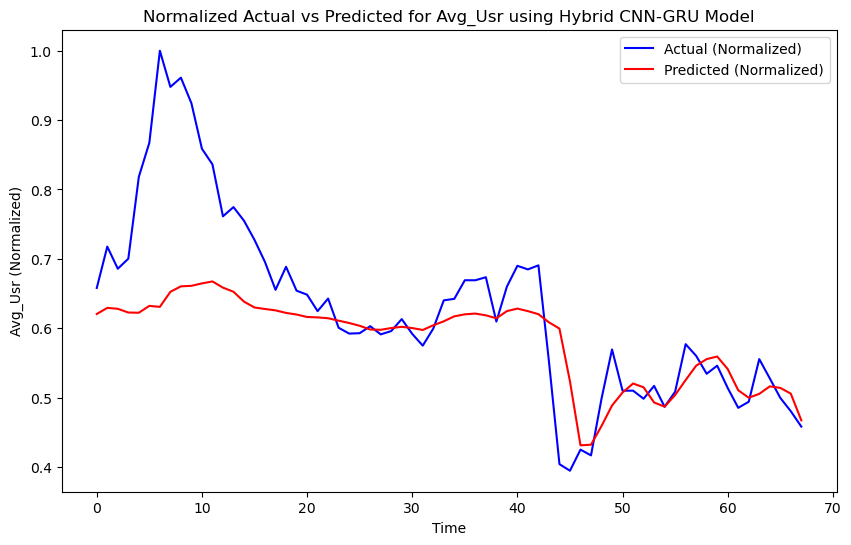

In [60]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-GRU model
def create_dataset_gru(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-GRU
X_train_gru, y_train_gru = create_dataset_gru(train_predict_svm, train, look_back=look_back)
X_test_gru, y_test_gru = create_dataset_gru(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and GRU input
X_train_gru = np.reshape(X_train_gru, (X_train_gru.shape[0], X_train_gru.shape[1], 2))  # Two features: original and SVM
X_test_gru = np.reshape(X_test_gru, (X_test_gru.shape[0], X_test_gru.shape[1], 2))

# Define the CNN-GRU model
def build_cnn_gru_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # GRU layers
    model.add(GRU(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(GRU(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-GRU model
cnn_gru_model = build_cnn_gru_model((look_back, 2))
cnn_gru_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-GRU model
train_predict_gru = cnn_gru_model.predict(X_train_gru)
test_predict_gru = cnn_gru_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_gru, test_predict_gru)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_gru, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

Epoch 1/50
9/9 [==============================] - 10s 160ms/step - loss: 0.2803 - val_loss: 0.3099
Epoch 2/50
9/9 [==============================] - 0s 12ms/step - loss: 0.1906 - val_loss: 0.1618
Epoch 3/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0673 - val_loss: 0.0039
Epoch 4/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0173 - val_loss: 0.0111
Epoch 5/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0111 - val_loss: 0.0065
Epoch 6/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0122 - val_loss: 0.0074
Epoch 7/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0080 - val_loss: 2.1711e-04
Epoch 8/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0090 - val_loss: 3.4999e-04
Epoch 9/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0069 - val_loss: 0.0039
Epoch 10/50
9/9 [==============================] - 0s 8ms/step - loss: 0.0077 - val_loss: 3.5838e-04
Epoch 11/50
9/9 [=====

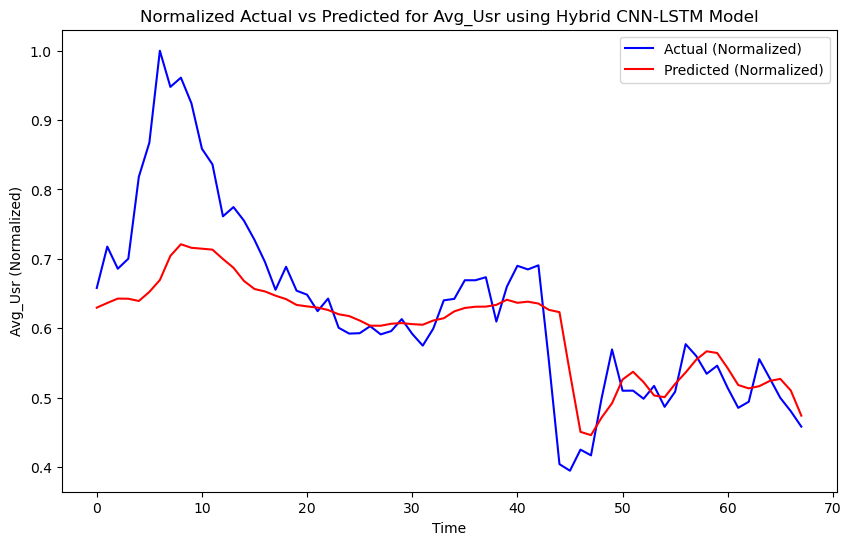

In [61]:
# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'AVG_NO_USER'
feature = 'AVG_NO_USER'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for SVM (look_back=3)
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Train SVM model
svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM model
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for CNN-LSTM model
def create_dataset_lstm(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series data and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Creating datasets for CNN-LSTM
X_train_lstm, y_train_lstm = create_dataset_lstm(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_lstm(test_predict_svm, test, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for CNN and LSTM input
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))  # Two features: original and SVM
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Define the CNN-LSTM model
def build_cnn_lstm_model(input_shape):
    model = Sequential()
    
    # 1D CNN layers
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape))
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.2))
    
    # LSTM layers
    model.add(LSTM(100, return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    
    # Dense output layer
    model.add(Dense(1))
    
    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Build and train CNN-LSTM model
cnn_lstm_model = build_cnn_lstm_model((look_back, 2))
cnn_lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the CNN-LSTM model
train_predict_lstm = cnn_lstm_model.predict(X_train_lstm)
test_predict_lstm = cnn_lstm_model.predict(X_test_lstm)

# Calculate normalized MSE
normalized_mse = mean_squared_error(y_test_lstm, test_predict_lstm)
print(f'Normalized MSE: {normalized_mse}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_lstm, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Hybrid CNN-LSTM Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [62]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

Epoch 1/50
9/9 [==============================] - 7s 108ms/step - loss: 0.1377 - val_loss: 0.0135
Epoch 2/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0144 - val_loss: 0.0129
Epoch 3/50
9/9 [==============================] - 0s 9ms/step - loss: 0.0095 - val_loss: 0.0041
Epoch 4/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0077 - val_loss: 0.0031
Epoch 5/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0057 - val_loss: 2.6173e-04
Epoch 6/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0060 - val_loss: 8.5386e-04
Epoch 7/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0055 - val_loss: 0.0029
Epoch 8/50
9/9 [==============================] - 0s 15ms/step - loss: 0.0052 - val_loss: 3.7092e-04
Epoch 9/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0060 - val_loss: 9.8686e-04
Epoch 10/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0057 - val_loss: 0.0016
Epoch 11/50
9

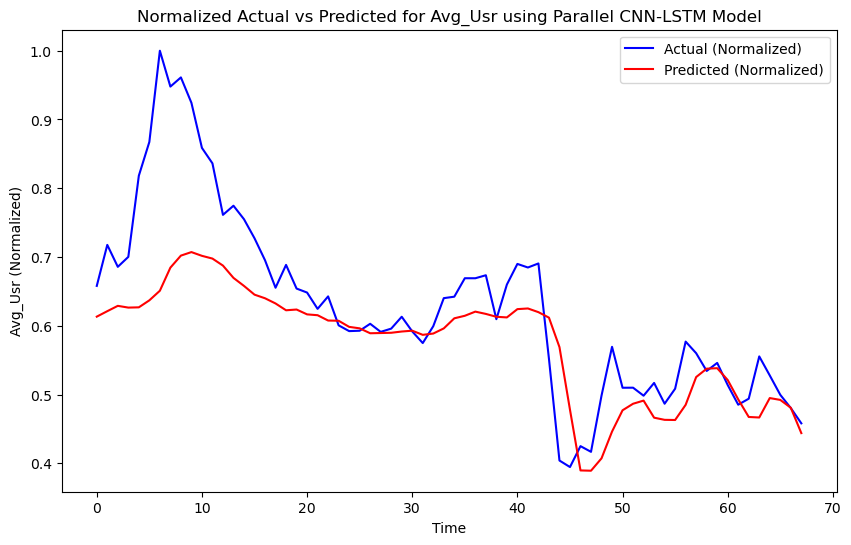

In [63]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, LSTM, Dense, Dropout, concatenate, Flatten
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Define the input shape
input_shape = (look_back, 2)  # look_back timesteps, 2 features (SVM and original)

# Define input layer
input_layer = Input(shape=input_shape)

# CNN Path
cnn = Conv1D(filters=64, kernel_size=2, activation='relu')(input_layer)
cnn = MaxPooling1D(pool_size=2)(cnn)
cnn = Dropout(0.2)(cnn)
cnn = Flatten()(cnn)  # Flatten CNN output to 2D

# LSTM Path
lstm = LSTM(100, return_sequences=False)(input_layer)
lstm = Dropout(0.2)(lstm)

# Merge the outputs of both paths
merged = concatenate([cnn, lstm])

# Fully connected layer
dense = Dense(50, activation='relu')(merged)
output = Dense(1)(dense)

# Build and compile the model
parallel_model = Model(inputs=input_layer, outputs=output)
parallel_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
parallel_model.fit(X_train_gru, y_train_gru, epochs=50, batch_size=32, validation_split=0.1, verbose=1)

# Predict with the parallel CNN-LSTM model
train_predict_parallel = parallel_model.predict(X_train_gru)
test_predict_parallel = parallel_model.predict(X_test_gru)

# Calculate normalized MSE
normalized_mse_parallel = mean_squared_error(y_test_gru, test_predict_parallel)
print(f'Normalized MSE: {normalized_mse_parallel}')

# Plot the normalized actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(y_test_gru, label='Actual (Normalized)', color='blue')
plt.plot(test_predict_parallel, label='Predicted (Normalized)', color='red')
plt.title('Normalized Actual vs Predicted for Avg_Usr using Parallel CNN-LSTM Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr (Normalized)')
plt.legend()
plt.show()

In [64]:
# Load your dataset (adjust the path to where your file is located)
#data = pd.read_csv('../../data/Site3data.csv')